## Introduction 

### Research Questions (Q):

1. Which genres are the most common (number of movies made)?
2. Which genres have high avg. budget and revenue?
2.5 Which genres have high avg. Profit?
3. Which genres have high avg. popularity?
4. Which genres have highest number of movies with an votion avg. >=8 ?

### Research Hyphotheses (H):

1. The best movies according to vote avg.return high profit and revenue.
2. The best movies according to popularity return high profit and revenue.
3. Highly budgeted movies return high revenue and profit.
4. Highly budgeted movies have a high popularity.



In [1]:
import pandas as pd

movies = pd.read_csv(r'C:\Users\rados\OneDrive\Desktop\Python Pandas Project\imdb_movies.csv')

#movies

In [ ]:
movies.info()

In [ ]:
movies.head()

In [2]:
pd.set_option('display.max.rows', 11000)
pd.set_option('display.max.columns', 22)

In [ ]:
movies.drop_duplicates(inplace = True)

In [5]:
movies.dropna(subset = ['genres'], inplace = True)

In [6]:
movies['profit'] = movies['revenue'] - movies['budget']

In [9]:
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres','release_date','vote_count','vote_average', 'profit']]

In [8]:
movies_genre.head()

NameError: name 'movies_genre' is not defined

In [3]:
from pandas import Series, DataFrame
import matplotlib.pyplot as plt

In [10]:
split = movies_genre['genres'].str.split('|', expand=True).stack()
split.index = split.index.droplevel(-1)
split.name = 'genres_split'
del movies_genre['genres']
movies_genre = movies_genre.join(split)

In [ ]:
movies_genre

### Research Questions (Q):

1. Which genres are the most common (number of movies made)?

In [11]:
genres_count = pd.DataFrame(movies_genre.groupby('genres_split').original_title.nunique()).sort_values('original_title',ascending = True)

In [ ]:
genres_count

<Axes: title={'center': 'Movies Per Genre in %'}, ylabel='original_title'>

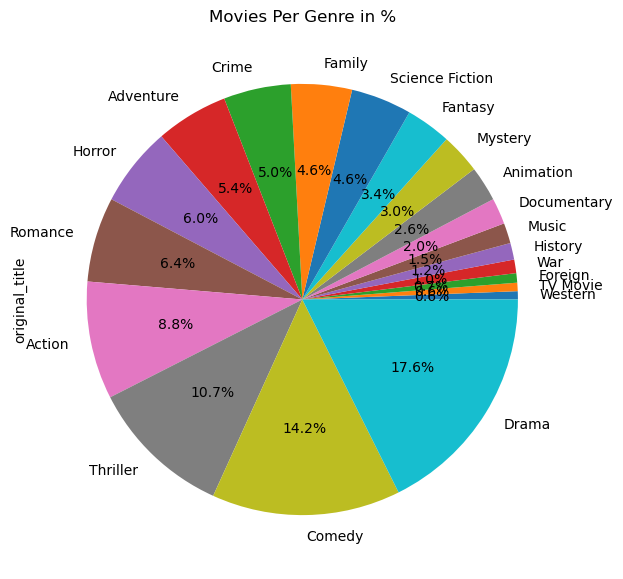

In [13]:
genres_count['original_title'].plot.pie(title = 'Movies Per Genre in %', autopct = '%1.1f%%', figsize = (7,7))

<Axes: title={'center': 'Movies Per Genre'}, ylabel='genres_split'>

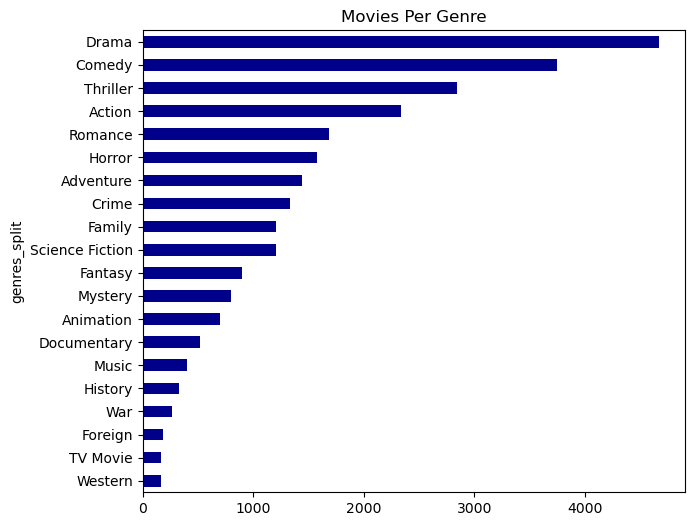

In [15]:
genres_count['original_title'].plot.barh(title = 'Movies Per Genre', color= 'DarkBlue', figsize = (7,6))

2. Which genres have high avg. budget and revenue?

In [16]:
genres_avg = movies_genre.groupby('genres_split').mean(numeric_only=True)
#pd.options.display.float_format = '{:2f}'.format
genres_avg


,popularity,budget,revenue,runtime,vote_count,vote_average,profit
genres_split,,,,,,,
Action,0.926136,2.772877e+07,7.276462e+07,104.912369,392.875052,5.787421,4.503584e+07
Adventure,1.154259,3.754369e+07,1.131379e+08,106.173351,513.125085,5.940585,7.559417e+07
Animation,0.852182,2.315978e+07,7.525606e+07,68.181688,303.000000,6.403147,5.209628e+07
Comedy,0.592607,1.329792e+07,3.752624e+07,96.745057,176.436330,5.905167,2.422833e+07
Crime,0.744821,1.767291e+07,4.233811e+07,106.906273,278.680443,6.124059,2.466520e+07
Documentary,0.181432,5.771491e+05,2.041107e+06,102.651923,35.105769,6.908462,1.463958e+06
Drama,0.591496,1.188452e+07,2.922632e+07,110.474270,182.529301,6.165301,1.734180e+07
Family,0.786668,2.335934e+07,7.243318e+07,89.603574,272.320877,5.997563,4.907384e+07
Fantasy,0.992840,3.261259e+07,9.631366e+07,100.736900,420.741266,5.863537,6.370107e+07


In [17]:
genres_avg.sort_values('budget', ascending = True, inplace = True)

<Axes: title={'center': 'Budget And Revenue by Genre'}, ylabel='genres_split'>

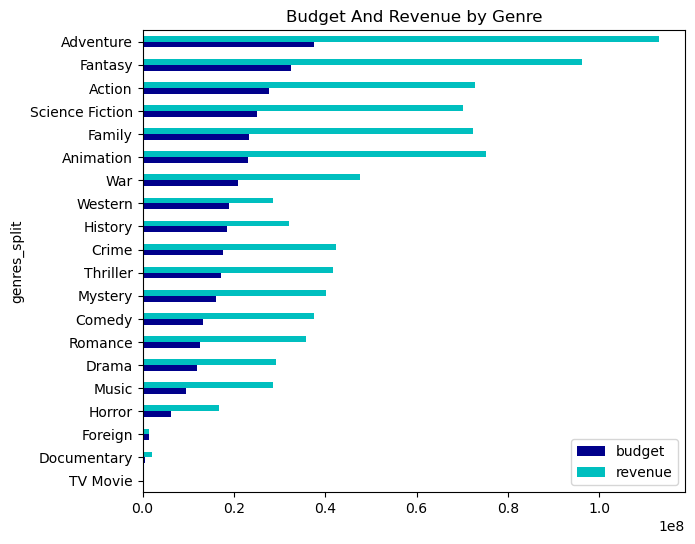

In [19]:
genres_avg[['budget', 'revenue']].plot.barh(title = 'Budget And Revenue by Genre', color= ('DarkBlue','c'), figsize = (7,6))

In [ ]:
genres_avg.sort_values('revenue', ascending = True, inplace = True)

In [ ]:
genres_avg[['budget', 'revenue']].plot.barh(title = 'Budget And Revenue by Genre', color= ('DarkBlue','c'), figsize = (10,9))

2.5 Which genres have high avg. Profit?

In [ ]:
movies_avg 

In [20]:
genres_avg.sort_values('profit', ascending = True, inplace = True)

<Axes: title={'center': 'Profit by Genre'}, ylabel='genres_split'>

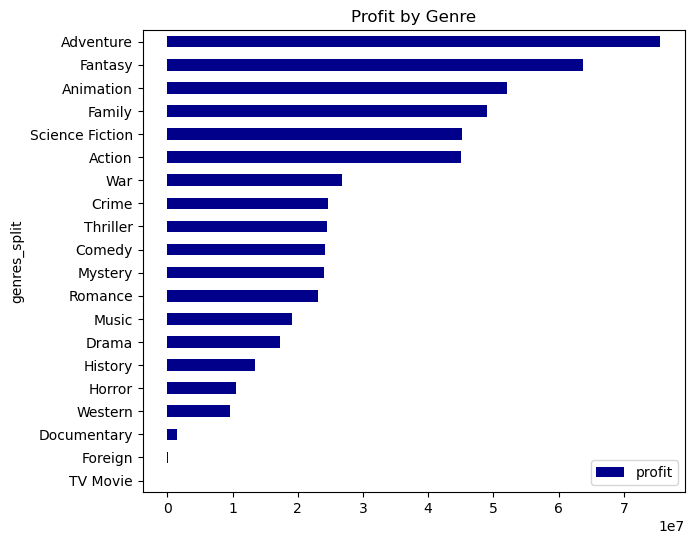

In [21]:
genres_avg[['profit']].plot.barh(title = 'Profit by Genre', color= 'DarkBlue', figsize = (7,6))

3. Which genres have high avg. popularity?

In [22]:
genres_avg.sort_values('popularity', ascending = True, inplace = True)

<Axes: title={'center': 'Popularity by Genre'}, ylabel='genres_split'>

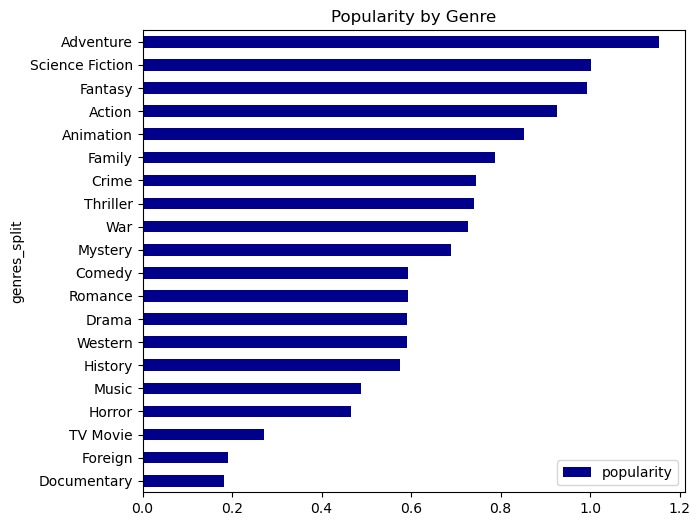

In [24]:
genres_avg[['popularity']].plot.barh(title = 'Popularity by Genre', color= 'DarkBlue', figsize = (7,6))

4. Which genres have highest number of movies with an votion avg. >=8 ?

In [ ]:
movies_genre.head()

In [26]:
vote_fifty = movies_genre[(movies_genre['vote_count']>= 50) & (movies_genre['vote_average']>= 8)]
vote_zero = movies_genre[movies_genre['vote_average']>= 8]

In [27]:
genres_vote = pd.DataFrame(vote_fifty.groupby('genres_split').vote_average.nunique()).sort_values('vote_average',ascending = True)

In [ ]:
genres_vote

<Axes: title={'center': 'Vote_average by Genre'}, ylabel='genres_split'>

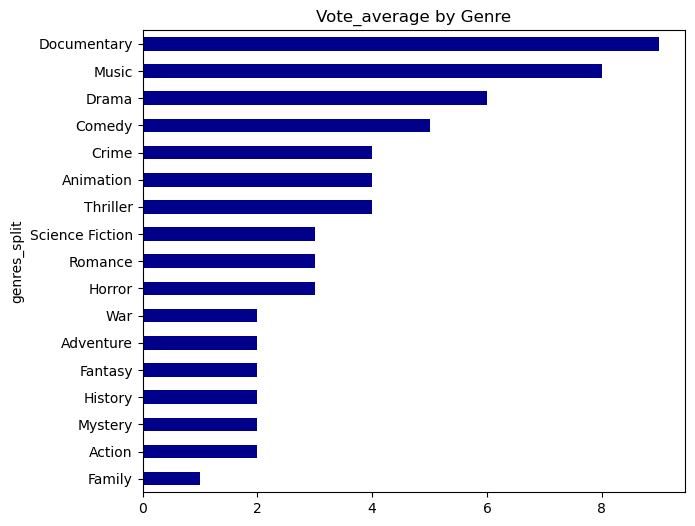

In [30]:
genres_vote['vote_average'].plot.barh(title = 'Vote_average by Genre', color= 'DarkBlue', figsize = (7,6))

In [29]:
genres_vote = pd.DataFrame(vote_zero.groupby('genres_split').vote_average.nunique()).sort_values('vote_average',ascending = True)

<Axes: title={'center': 'Vote_average by Genre'}, ylabel='genres_split'>

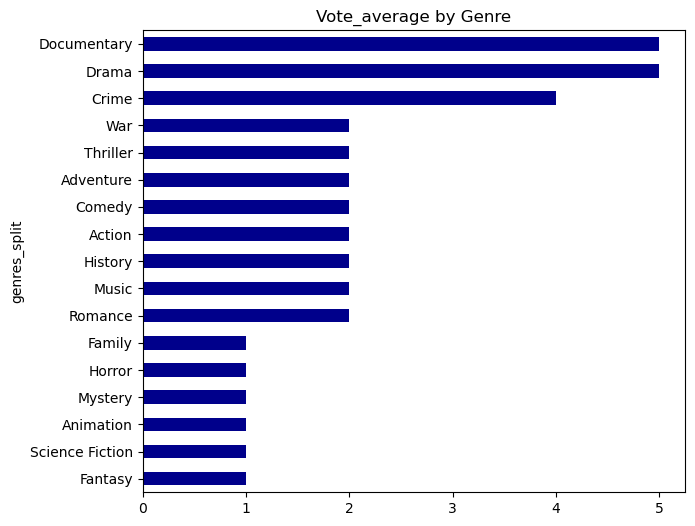

In [28]:
genres_vote['vote_average'].plot.barh(title = 'Vote_average by Genre', color= 'DarkBlue', figsize = (7,6))

### Research Hyphotheses (H):

1. The best movies according to vote avg.return high profit and revenue.

In [ ]:
movies.drop_duplicates(inplace = True)
movies['profit'] = movies['revenue'] - movies['budget']
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres','release_date','vote_count','vote_average', 'profit']]

In [ ]:
movies_counted = movies_genre[movies_genre['vote_count']>=50]

movies_counted.corr(method='spearman', numeric_only=True)

In [ ]:
import seaborn as sns
sns.regplot(x = 'vote_average', y = 'profit', data = movies_counted, line_kws = {"color":'red'})
#movies_counted.plot.scatter(x = 'vote_average', y = 'profit')


In [ ]:
sns.regplot(x = 'vote_average', y = 'revenue', data = movies_counted, line_kws = {"color":'red'})

2. The best movies according to popularity return high profit and revenue.

In [ ]:
sns.regplot(x = 'popularity', y = 'revenue', data = movies_counted, line_kws = {"color":'red'})

3. Highly budgeted movies return high profit.

In [ ]:
sns.regplot(x = 'budget', y = 'profit', data = movies_counted, line_kws = {"color":'red'})

4. Highly budgeted movies have a high popularity.

In [ ]:
sns.regplot(x = 'budget', y = 'popularity', data = movies_counted, line_kws = {"color":'red'})

In [ ]:
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres','release_year','vote_count','vote_average', 'profit']]

In [ ]:
movies_genre.head()

In [ ]:
time_genre = pd.DataFrame(movies_genre.groupby(['release_year', 'genres_split'])['profit'].mean())

In [ ]:
final_genre = pd.pivot_table(time_genre, values = 'profit', index = ['genres_split'], columns = ['release_year'])

In [ ]:
sns.set(rc= {'figure.figsize' : (10,6)})
sns.heatmap(final_genre, cmap = 'coolwarm',linewidths = .5)
plt.title('Genres By Profit Per Year')
